# Step 1: Data Exploration

Before touching any ML algorithms, we need to understand our data:
- What does it look like? (shape, types, missing values)
- How imbalanced is it? (normal vs anomaly ratio)
- What do the feature distributions look like?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load the Data

In [2]:
df = pd.read_csv("../data/creditcard.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 284,807 rows x 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Basic Info — Types, Missing Values, Duplicates

In [3]:
print(f"Data types:\n{df.dtypes.value_counts()}\n")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Data types:
float64    30
int64       1
Name: count, dtype: int64

Missing values: 0
Duplicate rows: 1081


In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 3. Class Distribution (Most Important!)

This tells us how imbalanced the dataset is.  
In anomaly detection, the whole challenge is that anomalies are **rare**.

In [6]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print(f"Normal (Class=0):  {class_counts[0]:,} ({class_pct[0]:.3f}%)")
print(f"Fraud  (Class=1):  {class_counts[1]:,} ({class_pct[1]:.3f}%)")
print(f"\nImbalance ratio: 1 fraud per {class_counts[0] // class_counts[1]} normal transactions")

Normal (Class=0):  284,315 (99.827%)
Fraud  (Class=1):  492 (0.173%)

Imbalance ratio: 1 fraud per 577 normal transactions


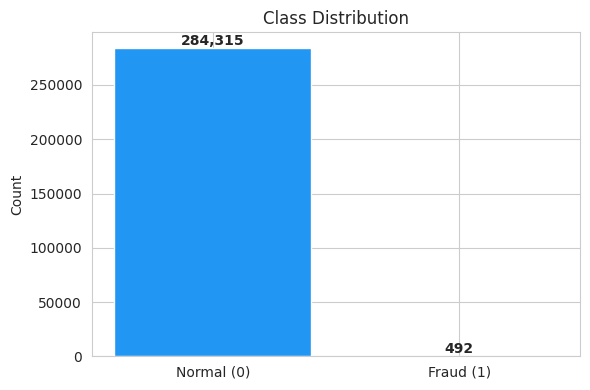

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#2196F3", "#F44336"]
bars = ax.bar(["Normal (0)", "Fraud (1)"], class_counts.values, color=colors)

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{count:,}", ha="center", va="bottom", fontweight="bold")

ax.set_ylabel("Count")
ax.set_title("Class Distribution")
plt.tight_layout()
plt.show()

## 4. Amount & Time Analysis

V1-V28 are PCA-transformed features (already scaled and anonymized).  
**Time** and **Amount** are the only original features we can interpret.

In [8]:
print(f"Time range: {df['Time'].min():.0f} - {df['Time'].max():.0f} seconds")
print(f"That's ~{df['Time'].max() / 3600:.1f} hours of transactions\n")

print("Amount by class:")
for cls in [0, 1]:
    subset = df[df["Class"] == cls]["Amount"]
    label = "Normal" if cls == 0 else "Fraud"
    print(f"  {label}: mean=${subset.mean():.2f}, median=${subset.median():.2f}, max=${subset.max():.2f}")

Time range: 0 - 172792 seconds
That's ~48.0 hours of transactions

Amount by class:
  Normal: mean=$88.29, median=$22.00, max=$25691.16
  Fraud: mean=$122.21, median=$9.25, max=$2125.87


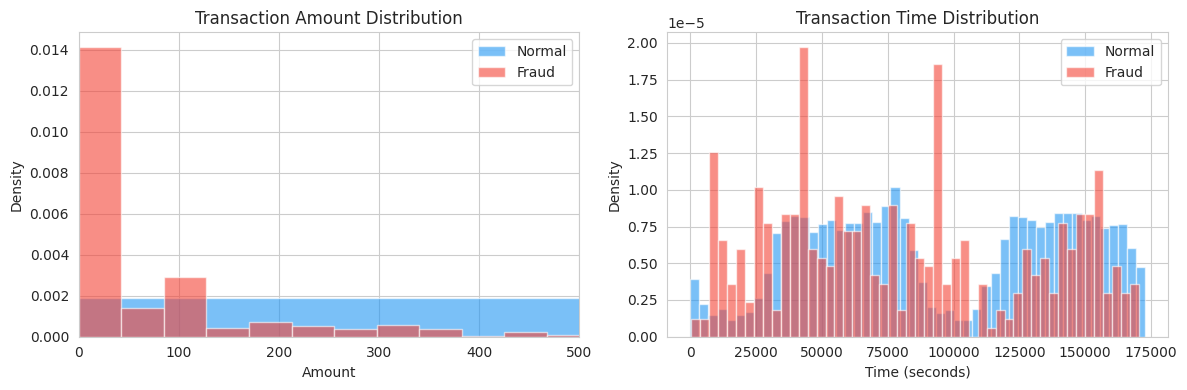

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Amount distribution
for cls, color, label in [(0, "#2196F3", "Normal"), (1, "#F44336", "Fraud")]:
    subset = df[df["Class"] == cls]["Amount"]
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Density")
axes[0].set_title("Transaction Amount Distribution")
axes[0].legend()
axes[0].set_xlim(0, 500)

# Time distribution
for cls, color, label in [(0, "#2196F3", "Normal"), (1, "#F44336", "Fraud")]:
    subset = df[df["Class"] == cls]["Time"]
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Density")
axes[1].set_title("Transaction Time Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Correlation Heatmap (V Features)

Since V1-V28 come from PCA, they should be mostly uncorrelated.  
This is a sanity check — if they're highly correlated, something is off.

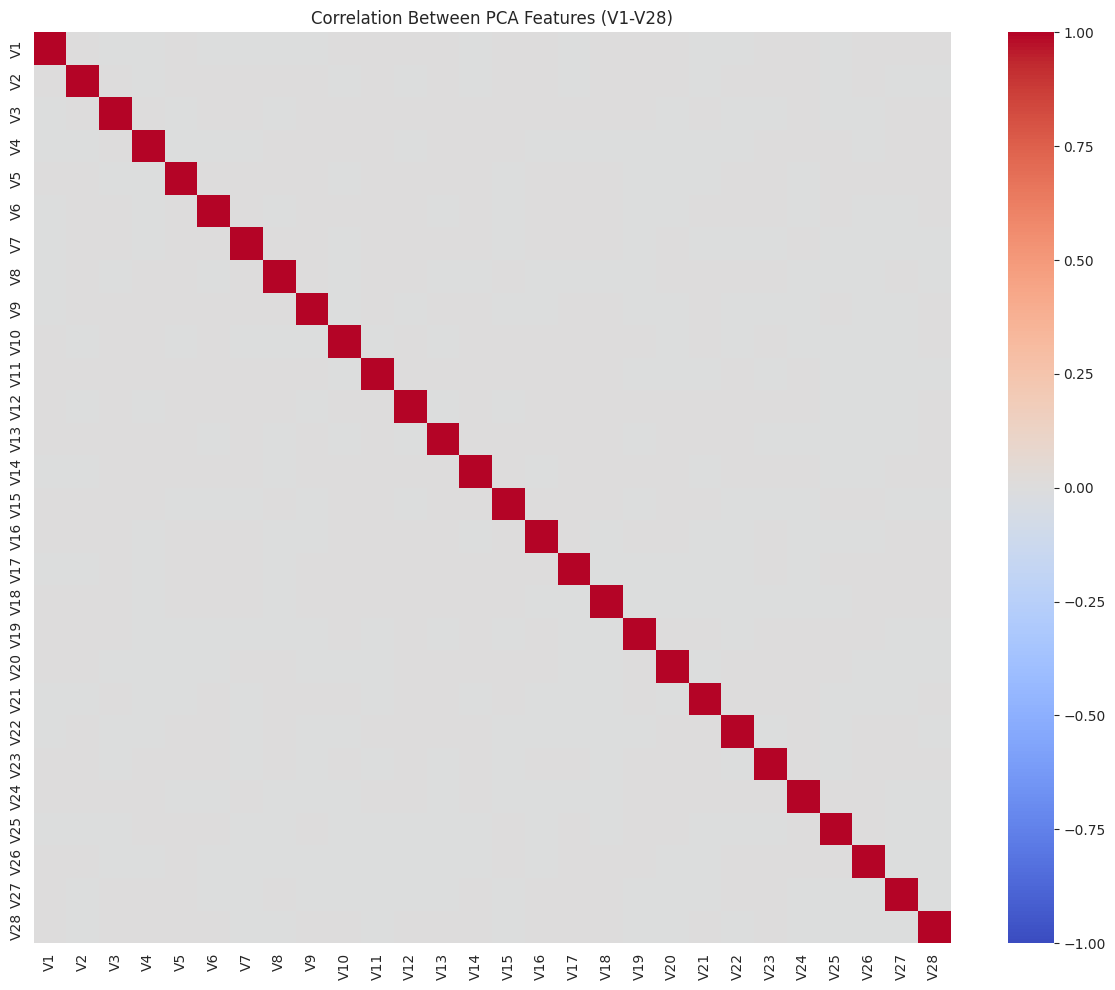

In [10]:
v_cols = [f"V{i}" for i in range(1, 29)]
corr_matrix = df[v_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Between PCA Features (V1-V28)")
plt.tight_layout()
plt.show()

## 6. Key Features — Normal vs Fraud

Let's compare distributions of select features between normal and fraud.  
Features where the distributions differ a lot will be the most useful for detection.

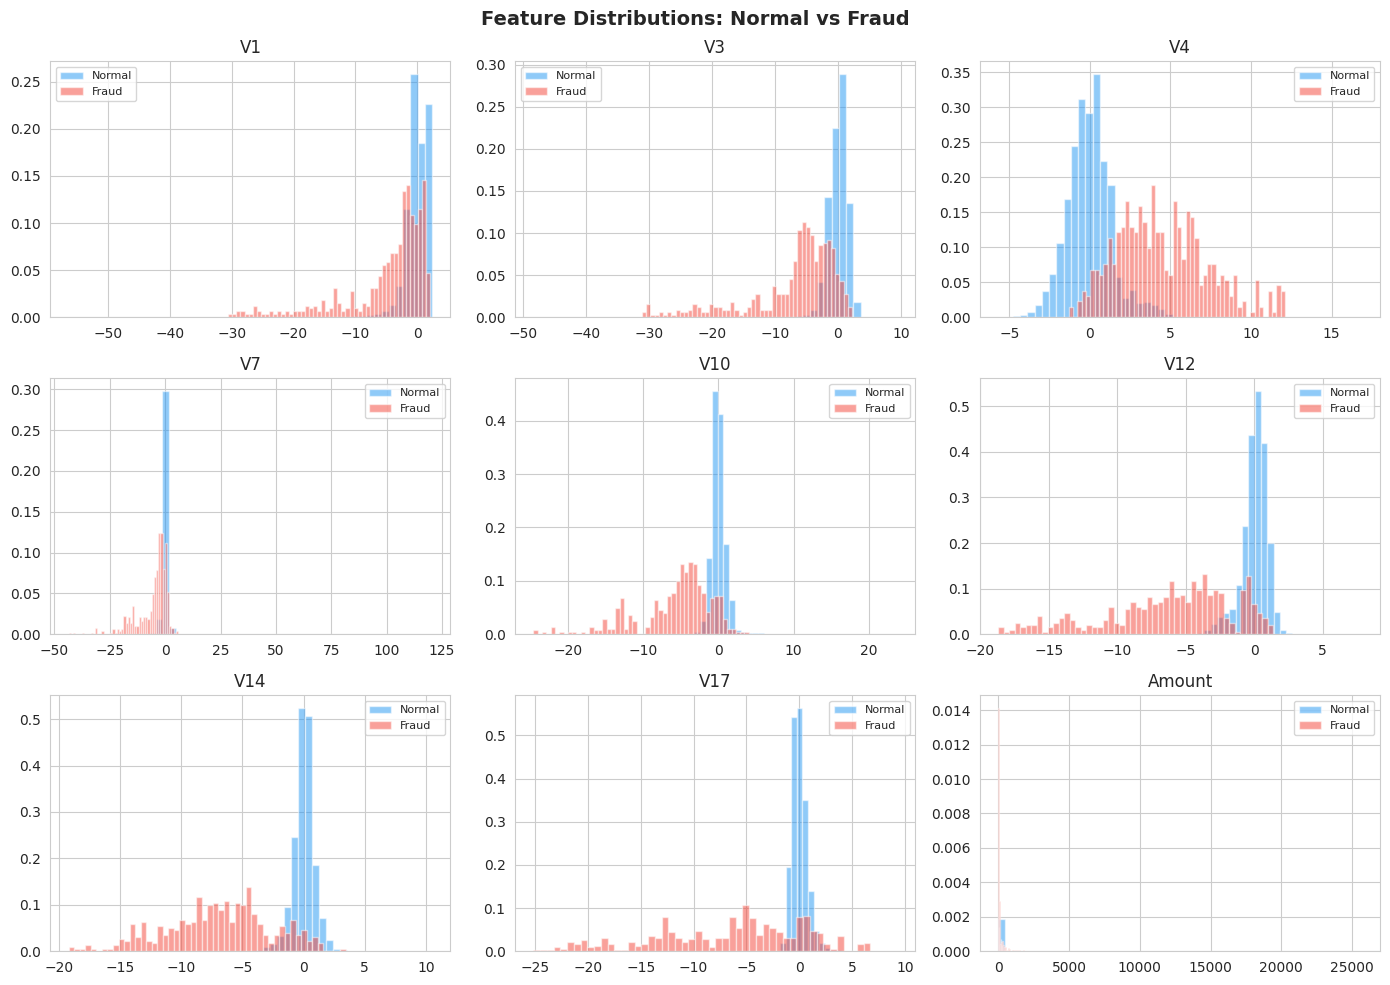

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
key_features = ["V1", "V3", "V4", "V7", "V10", "V12", "V14", "V17", "Amount"]

for ax, feat in zip(axes.ravel(), key_features):
    for cls, color, label in [(0, "#2196F3", "Normal"), (1, "#F44336", "Fraud")]:
        subset = df[df["Class"] == cls][feat]
        ax.hist(subset, bins=50, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions: Normal vs Fraud", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary

**What we learned:**
1. The dataset is extremely imbalanced — fraud is a tiny fraction
2. V1-V28 are PCA features (already scaled, mostly uncorrelated)
3. `Amount` needs scaling before ML (it's on a different scale than V features)
4. Some V features show clear distribution differences between normal and fraud

**Next step:** Preprocessing & training the 5 unsupervised algorithms